<div style="background: linear-gradient(135deg, #FF4A5A 0%, #FF8E53 100%); padding: 25px; border-radius: 10px; box-shadow: 0 4px 15px rgba(0,0,0,0.15); margin-bottom: 20px;">
    <h1 style="color: white; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin: 0; font-size: 32px; letter-spacing: 1px;">Anime Dataset Exploration & Insights</h1>
    <p style="color: #FFE3E5; font-style: italic; font-size: 15px; margin: 8px 0 0 0;">Exploratory Data Analysis on Types, Ratings, and Streaming Platforms</p>
</div>

<div style="border-left: 6px solid #FF4A5A; background-color: #FFF5F6; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">1. Data Loading & Library Initialization</h2>
</div>

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/devashish001/anime-dataset-with-ratings-and-streaming-platforms/anime_dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlepad'] = 15

In [3]:
df = pd.read_csv("/kaggle/input/datasets/devashish001/anime-dataset-with-ratings-and-streaming-platforms/anime_dataset.csv")
df.head()

,anime_id,title,synopsis,anime_type,episodes,status,aired_start,aired_end,year,rating,...,crunchyroll,amazon_prime,hulu,funimation,disney_plus,hbo_max,hidive,pokemon_tv,streaming_platforms_count,poster_url
0,1,Naruto,"Naruto Uzumaki, a mischievous adolescent ninja...",Shonen,220,Finished Airing,03-10-2002,08-02-2007,2002,7.9,...,https://www.crunchyroll.com/series/GR79MM93Y/n...,NaN,https://www.hulu.com/series/naruto-6ff9a8a2-0f...,NaN,NaN,NaN,NaN,NaN,3,https://cdn.myanimelist.net/images/anime/1141/...
1,2,Naruto: Shippuden,After 2 and a half years Naruto finally return...,Shonen,500,Finished Airing,15-02-2007,23-03-2017,2007,8.2,...,https://www.crunchyroll.com/series/GR79MM93Y/n...,NaN,https://www.hulu.com/series/naruto-shippuden-9...,NaN,NaN,NaN,NaN,NaN,3,https://cdn.myanimelist.net/images/anime/1565/...
2,3,Dragon Ball,Follows the adventures of an extraordinarily s...,Shonen,153,Finished Airing,26-02-1986,12-04-1989,1986,8.5,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball/,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/1887/...
3,4,Dragon Ball Z,"With the help of the powerful Dragonballs, a t...",Shonen,291,Finished Airing,26-04-1989,31-01-1996,1989,8.9,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball-z/,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/1277/...
4,5,Dragon Ball Super,"After waking up from decades of slumber, Beeru...",Shonen,131,Finished Airing,05-07-2015,25-03-2018,2015,8.3,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball-s...,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/7/746...


<div style="border-left: 6px solid #FF4A5A; background-color: #FFF5F6; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">2. Understanding Data</h2>
</div>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   anime_id                   206 non-null    int64  
 1   title                      206 non-null    object 
 2   synopsis                   206 non-null    object 
 3   anime_type                 206 non-null    object 
 4   episodes                   206 non-null    int64  
 5   status                     206 non-null    object 
 6   aired_start                206 non-null    object 
 7   aired_end                  196 non-null    object 
 8   year                       206 non-null    int64  
 9   rating                     204 non-null    float64
 10  popularity                 206 non-null    int64  
 11  genres                     206 non-null    object 
 12  genres_count               206 non-null    int64  
 13  netflix                    65 non-null     object 

In [5]:
df.head()

,anime_id,title,synopsis,anime_type,episodes,status,aired_start,aired_end,year,rating,...,crunchyroll,amazon_prime,hulu,funimation,disney_plus,hbo_max,hidive,pokemon_tv,streaming_platforms_count,poster_url
0,1,Naruto,"Naruto Uzumaki, a mischievous adolescent ninja...",Shonen,220,Finished Airing,03-10-2002,08-02-2007,2002,7.9,...,https://www.crunchyroll.com/series/GR79MM93Y/n...,NaN,https://www.hulu.com/series/naruto-6ff9a8a2-0f...,NaN,NaN,NaN,NaN,NaN,3,https://cdn.myanimelist.net/images/anime/1141/...
1,2,Naruto: Shippuden,After 2 and a half years Naruto finally return...,Shonen,500,Finished Airing,15-02-2007,23-03-2017,2007,8.2,...,https://www.crunchyroll.com/series/GR79MM93Y/n...,NaN,https://www.hulu.com/series/naruto-shippuden-9...,NaN,NaN,NaN,NaN,NaN,3,https://cdn.myanimelist.net/images/anime/1565/...
2,3,Dragon Ball,Follows the adventures of an extraordinarily s...,Shonen,153,Finished Airing,26-02-1986,12-04-1989,1986,8.5,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball/,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/1887/...
3,4,Dragon Ball Z,"With the help of the powerful Dragonballs, a t...",Shonen,291,Finished Airing,26-04-1989,31-01-1996,1989,8.9,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball-z/,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/1277/...
4,5,Dragon Ball Super,"After waking up from decades of slumber, Beeru...",Shonen,131,Finished Airing,05-07-2015,25-03-2018,2015,8.3,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball-s...,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/7/746...


In [6]:
df.describe()

,anime_id,episodes,year,rating,popularity,genres_count,streaming_platforms_count
count,206.000000,206.000000,206.000000,204.000000,2.060000e+02,206.000000,206.000000
mean,103.500000,38.281553,2014.160194,8.229412,1.530134e+06,3.961165,2.029126
std,59.611241,99.717398,8.395037,0.586143,1.467346e+06,1.121170,0.783442
min,1.000000,1.000000,1986.000000,4.600000,3.210980e+05,2.000000,1.000000
25%,52.250000,12.000000,2009.250000,7.900000,8.000000e+05,3.000000,1.000000
50%,103.500000,22.000000,2016.000000,8.300000,9.876540e+05,4.000000,2.000000
75%,154.750000,25.000000,2020.750000,8.600000,1.800000e+06,5.000000,2.750000
max,206.000000,1136.000000,2026.000000,9.300000,1.543210e+07,7.000000,4.000000


<div style="border-left: 6px solid #FF4A5A; background-color: #FFF5F6; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">3. Handling missing values</h2>
</div>

In [7]:
df.isnull().sum()

anime_id                       0
title                          0
synopsis                       0
anime_type                     0
episodes                       0
status                         0
aired_start                    0
aired_end                     10
year                           0
rating                         2
popularity                     0
genres                         0
genres_count                   0
netflix                      141
crunchyroll                   37
amazon_prime                 195
hulu                         134
funimation                   127
disney_plus                  205
hbo_max                      200
hidive                       193
pokemon_tv                   204
streaming_platforms_count      0
poster_url                     0
dtype: int64

In [8]:
platform_cols = [
    'netflix', 'crunchyroll', 'amazon_prime', 'hulu',
    'funimation', 'disney_plus', 'hbo_max',
    'hidive', 'pokemon_tv'
]

df['streaming_platforms'] = (
    df[platform_cols]
    .apply(lambda row: ', '.join(row.dropna().astype(str)), axis=1)
)
df = df.drop(columns=platform_cols)

In [9]:
df["streaming_platforms"]

0      https://www.netflix.com/title/70205012, https:...
1      https://www.netflix.com/title/70205012, https:...
2      https://www.crunchyroll.com/series/GRMG8ZQZR/d...
3      https://www.crunchyroll.com/series/GRMG8ZQZR/d...
4      https://www.crunchyroll.com/series/GRMG8ZQZR/d...
                             ...                        
201    https://www.netflix.com/title/70204970, https:...
202    https://www.netflix.com/title/81091393, https:...
203    https://www.crunchyroll.com/movies/demon-slaye...
204    https://www.netflix.com/title/80097571, https:...
205    https://www.crunchyroll.com/series/G6NQ5DWZ6/m...
Name: streaming_platforms, Length: 206, dtype: object

In [10]:
df.duplicated().sum()

np.int64(0)

<div style="border-left: 6px solid #FF4A5A; background-color: #FFF5F6; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">4. Data Visualization</h2>
</div>

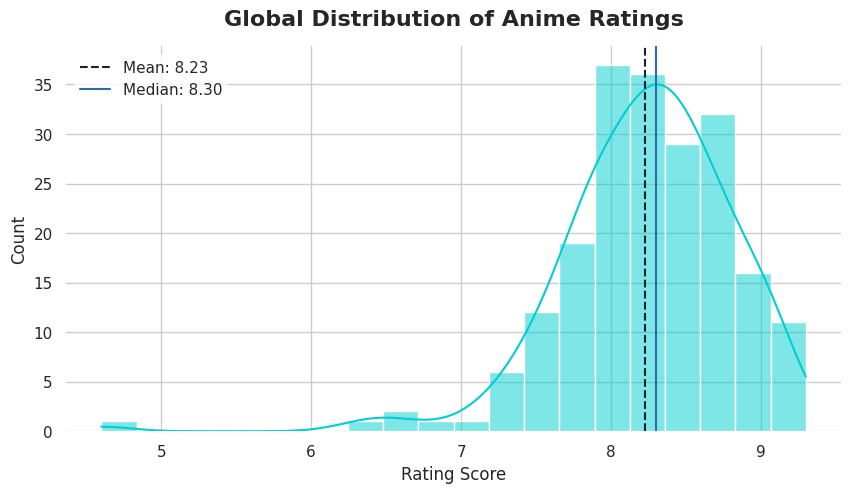

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='rating', kde=True, bins=20, color='#00CED1', edgecolor='white')

# Add context lines
mean_rating = df['rating'].mean()
median_rating = df['rating'].median()
plt.axvline(mean_rating, color='#1A202C', linestyle='--', linewidth=1.5, label=f"Mean: {mean_rating:.2f}")
plt.axvline(median_rating, color='#2B6CB0', linestyle='-', linewidth=1.5, label=f"Median: {median_rating:.2f}")

plt.title('Global Distribution of Anime Ratings')
plt.xlabel('Rating Score')
plt.ylabel('Count')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <p style="margin: 0; color: #334E68; font-size: 14px; line-height: 1.5;">
        Anime ratings are concentrated between 7.8 and 8.8, with a mean score of 8.23 and a median score of 8.30. The median being slightly higher than the mean indicates a small left-skew caused by a few lower-rated titles, while the majority of anime in the dataset receive generally favorable audience reviews.
    </p>
</div>

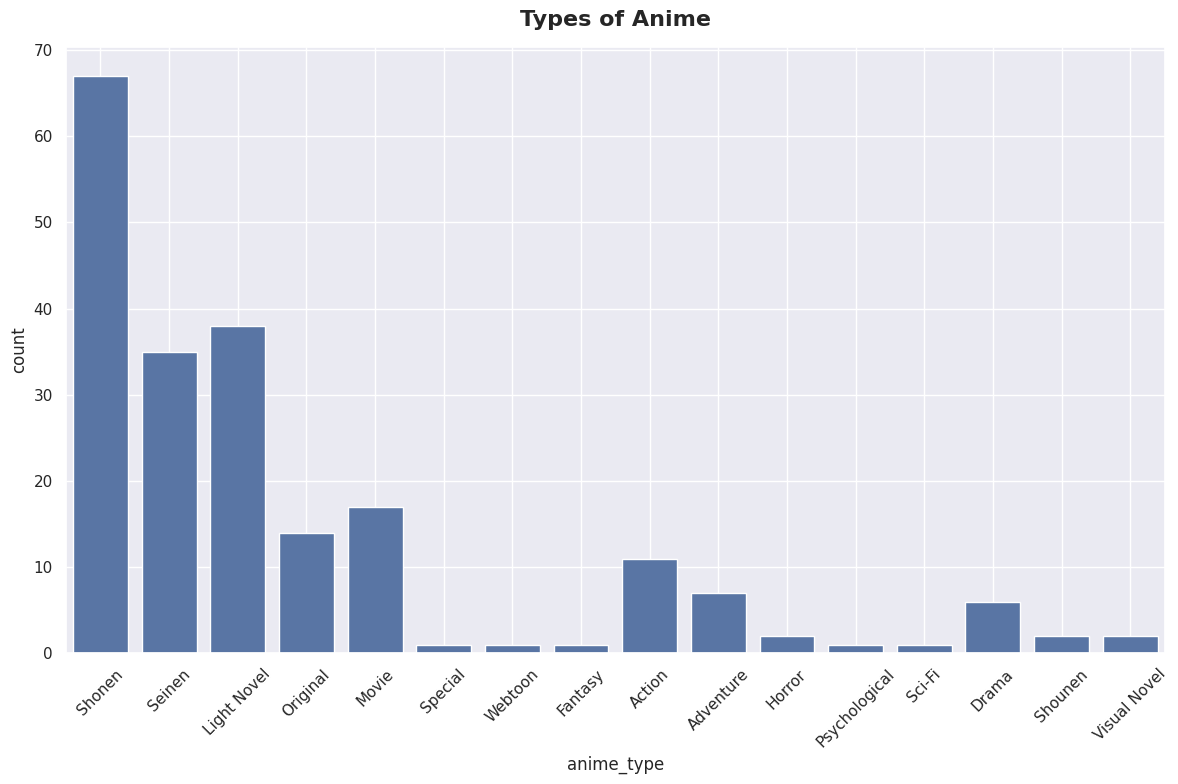

In [12]:
sns.set_style("dark")
plt.figure(figsize=(12,8))
sns.countplot(x="anime_type", data=df)
plt.title("Types of Anime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <p style="margin: 0; color: #334E68; font-size: 14px; line-height: 1.5;">
        Shonen anime represents the largest segment of the dataset, followed by Light Novel and Seinen adaptations. Niche categories such as Webtoon, Fantasy, Psychological, and Sci-Fi appear far less frequently, highlighting the industry's continued reliance on popular mainstream source materials.
    </p>
</div>

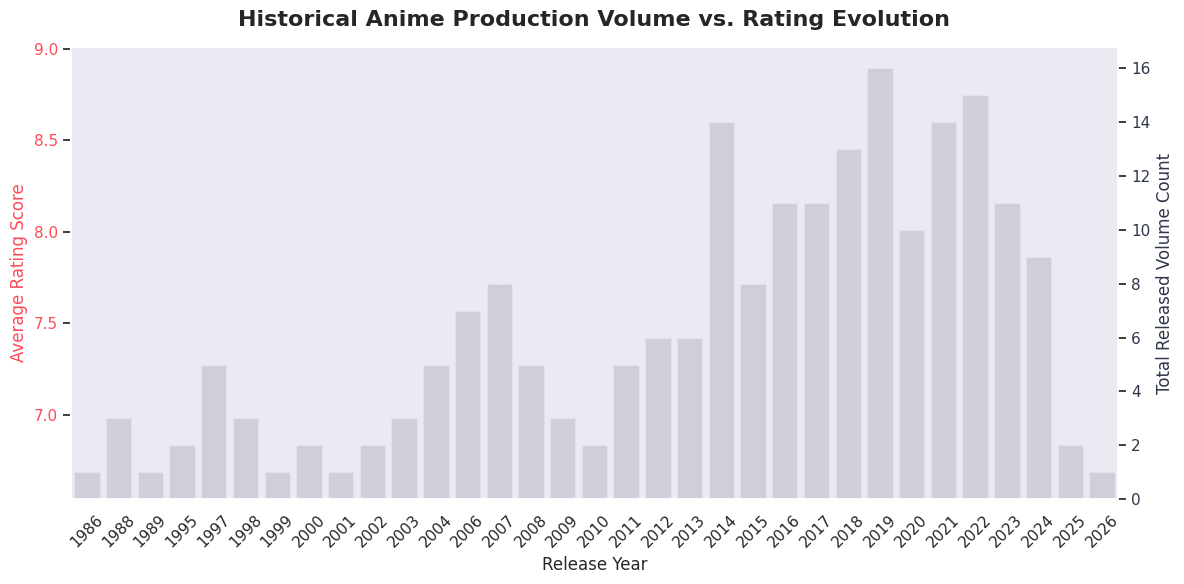

In [13]:
# Aggregate structural metrics across years
yearly_stats = df.groupby('year').agg({'rating': 'mean', 'anime_id': 'count'}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis line for ratings trajectory
color_line = '#FF4A5A'
ax1.set_xlabel('Release Year')
plt.xticks(rotation=45)
ax1.set_ylabel('Average Rating Score', color=color_line)
sns.lineplot(data=yearly_stats, x='year', y='rating', ax=ax1, color=color_line, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color_line)

# Secondary axis bar chart for historical volume distribution
ax2 = ax1.twinx()
color_bar = '#2D3748'
ax2.set_ylabel('Total Released Volume Count', color=color_bar)
sns.barplot(data=yearly_stats, x='year', y='anime_id', ax=ax2, color=color_bar, alpha=0.15)
ax2.tick_params(axis='y', labelcolor=color_bar)

plt.title('Historical Anime Production Volume vs. Rating Evolution')
fig.tight_layout()
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <p style="margin: 0; color: #334E68; font-size: 14px; line-height: 1.5;">
        Anime production volume has increased substantially since the mid-2010s, peaking around 2019–2022. Despite this growth in output, average ratings remain relatively stable, suggesting that the expansion of anime production has not significantly diluted overall content quality.
    </p>
</div>

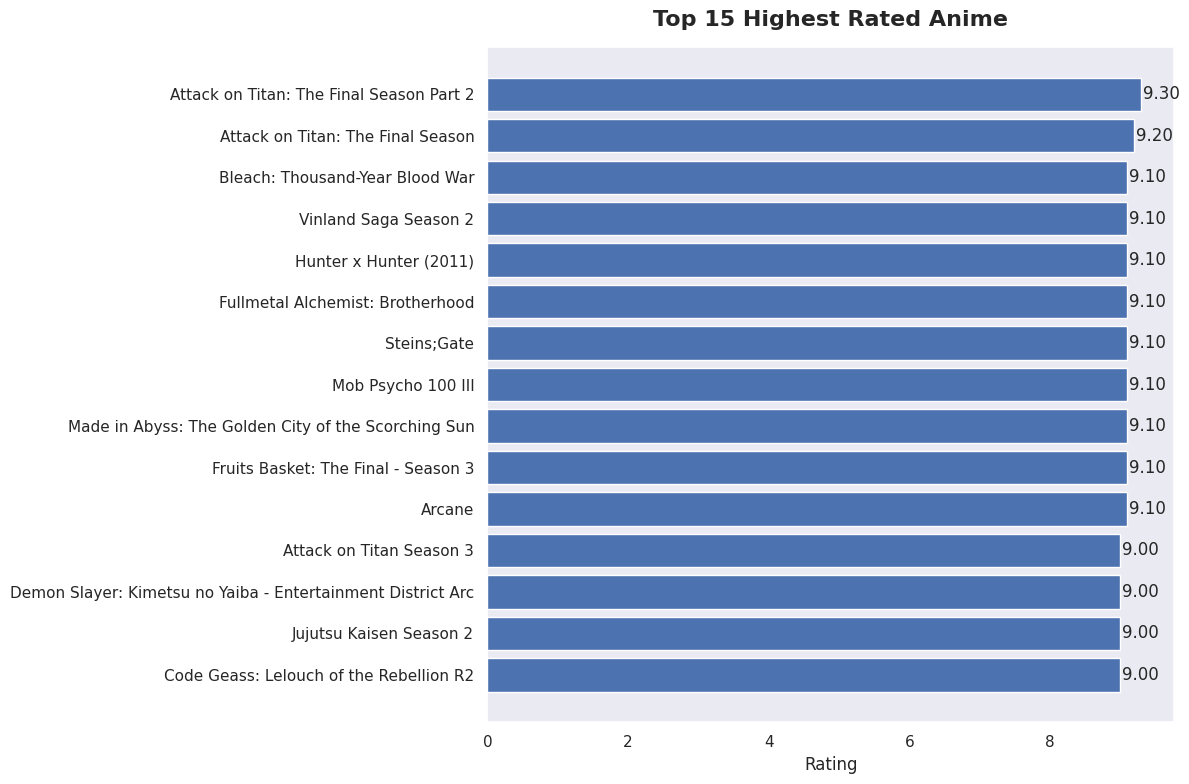

In [14]:
top_15 = df.nlargest(15, 'rating')[['title', 'rating']]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top_15['title'], top_15['rating'])

for bar in bars:
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.2f}',
        va='center'
    )

ax.invert_yaxis()
ax.set_xlabel('Rating')
ax.set_title('Top 15 Highest Rated Anime')
plt.tight_layout()
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <p style="margin: 0; color: #334E68; font-size: 14px; line-height: 1.5;">
        Attack on Titan: The Final Season Part 2 holds the highest rating in the dataset (9.3). The leaderboard is dominated by critically acclaimed modern titles such as Attack on Titan, Vinland Saga, Arcane, and Bleach: Thousand-Year Blood War, reflecting strong audience preference for high-production-value storytelling and character-driven narratives.
    </p>
</div>

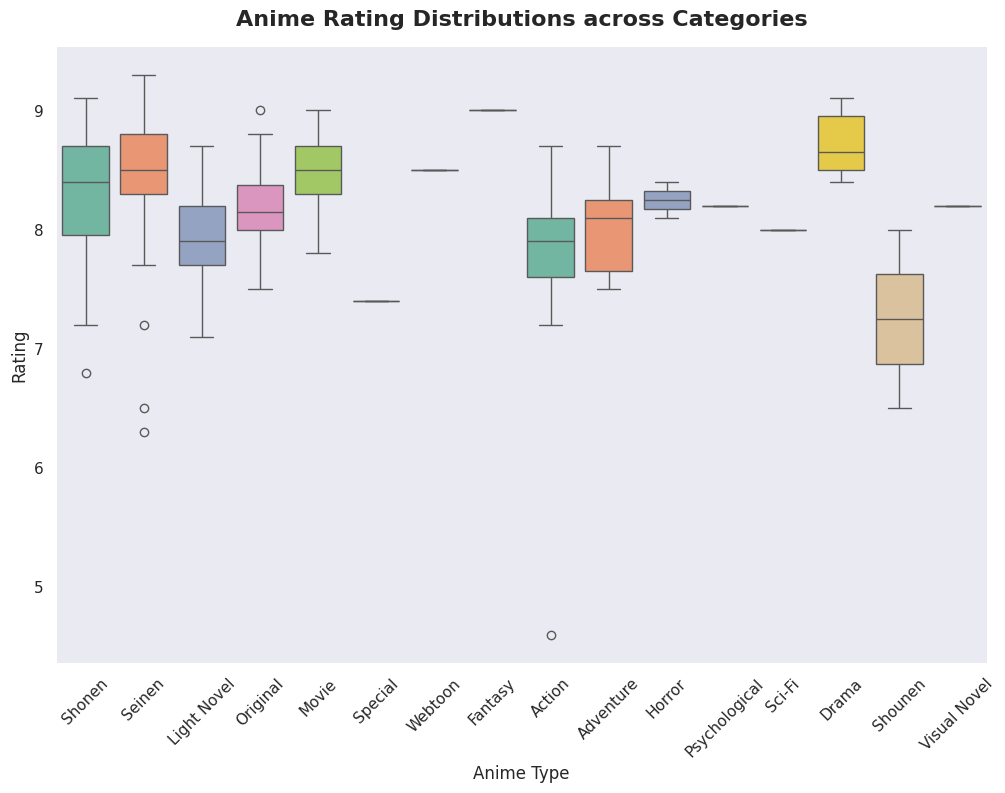

In [15]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='anime_type', y='rating', hue='anime_type', palette='Set2', legend=False)

plt.title('Anime Rating Distributions across Categories')
plt.xlabel('Anime Type')
plt.ylabel('Rating')
plt.xticks(rotation=45)
sns.despine(left=True, bottom=True)
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <p style="margin: 0; color: #334E68; font-size: 14px; line-height: 1.5;">
        Movie, Seinen, and Drama anime exhibit the highest median ratings, indicating consistently strong audience reception. Shonen titles show greater variability in ratings, suggesting a wider range of quality and audience preferences. Fantasy, Webtoon, and Special categories contain very few observations, so their ratings should be interpreted cautiously.
    </p>
</div>

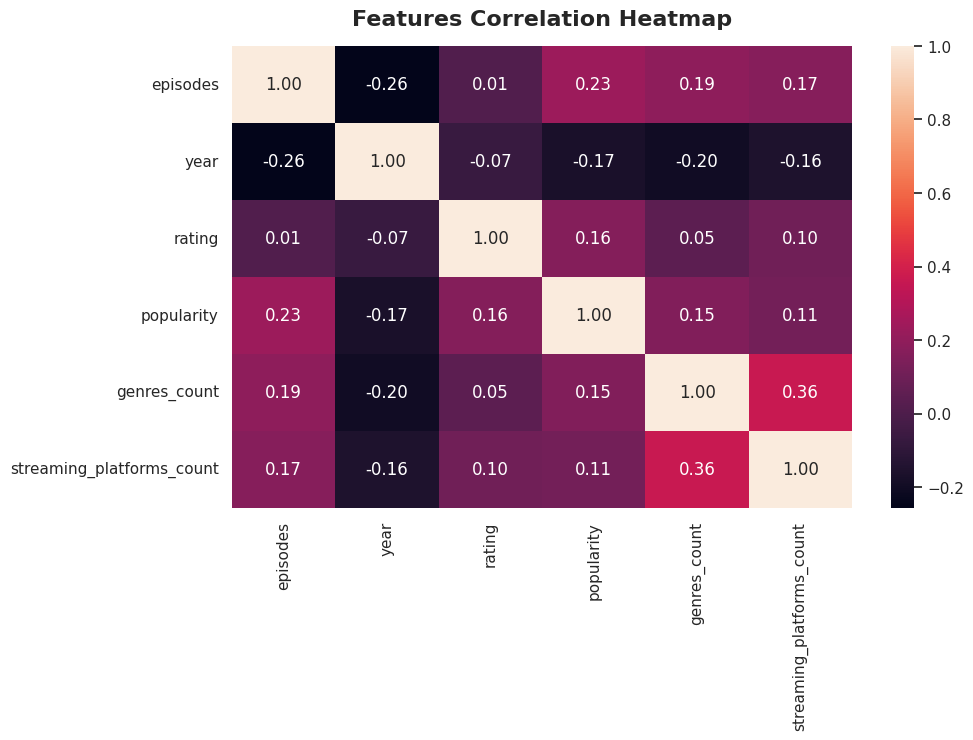

In [16]:
num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols[1:]
corr_mat = df[num_cols].corr()
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f"
)
plt.title("Features Correlation Heatmap")
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <p style="margin: 0; color: #334E68; font-size: 14px; line-height: 1.5;">
        Most numerical features show weak correlations, indicating that anime ratings are influenced by multiple independent factors rather than a single dominant variable. The strongest positive relationship exists between genre diversity and platform availability (0.36), suggesting that anime covering more genres tend to be distributed across more streaming platforms.
    </p>
</div>

<div style="border-left: 6px solid #FF4A5A; background-color: #FFF5F6; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">5. Conclusion</h2>
</div>

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 18px 20px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 16px; display: block; margin-bottom: 10px;">📌 Summary of Findings</span>
    <ul style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li><b>Ratings are strong and tightly clustered.</b> Across 206 titles, ratings average 8.23 with a median of 8.30, and the bulk of entries fall between roughly 7.8 and 8.8, this dataset skews toward well-received, popular anime rather than a random cross-section of all anime ever produced.</li>
        <li><b>Shonen dominates the catalogue.</b> It is the single largest category by count, with Light Novel and Seinen adaptations following behind, reflecting the industry's continued reliance on proven, mainstream source material over niche genres like Webtoon, Fantasy, or Psychological.</li>
        <li><b>Production has scaled up without sacrificing quality.</b> Output volume rose sharply from the mid-2010s onward, peaking around 2019–2022, yet average ratings held steady across that period rather than declining, more anime did not mean weaker anime.</li>
        <li><b>Modern, high-production titles lead the leaderboard.</b> <i>Attack on Titan: The Final Season Part 2</i> tops the list at 9.3, with the rest of the top 15 dominated by titles like <i>Vinland Saga</i>, <i>Arcane</i>, and <i>Bleach: Thousand-Year Blood War</i> series known for cinematic visuals and character-driven storytelling.</li>
        <li><b>Category matters for both quality and consistency.</b> Movie, Seinen, and Drama entries post the highest median ratings, while Shonen shows the widest spread, a mix of breakout hits and weaker entries. Categories with very few samples (Fantasy, Webtoon, Special) should be read with caution given limited representation.</li>
        <li><b>No single numeric feature drives rating.</b> The correlation heatmap shows mostly weak relationships between numeric fields, with the clearest signal being a moderate positive link (0.36) between genre diversity and the number of streaming platforms an anime is available on broader-appeal anime tend to be more widely distributed.</li>
    </ul>
</div>

<div style="background: linear-gradient(135deg, #FF4A5A 0%, #FF8E53 100%); padding: 20px 25px; border-radius: 10px; box-shadow: 0 4px 15px rgba(0,0,0,0.15); margin: 20px 0;">
    <p style="color: white; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 0; font-size: 15px; line-height: 1.6;">
        <b>Takeaway:</b> This dataset paints a picture of a maturing anime industry, one that has grown its output significantly over the last decade without diluting audience reception, and where genre choice still shapes both how well a title is received and how widely it travels across streaming platforms. Ratings here are influenced by a combination of factors (type, era, distribution reach) rather than any one dominant variable, which is itself a useful signal for anyone building a recommendation or rating-prediction model on top of this data.
    </p>
</div>
